In [1]:
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Model Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Evaluasi
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

# Simpan model
import joblib

# Ignore warning
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Sales - Marketing customer dataset.csv')

In [3]:
#menampilkan dataset
df.head()

,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


In [4]:
#informasi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  object 
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  object 
 4   city                        15000 non-null  object 
 5   signup_date                 15000 non-null  object 
 6   last_purchase_date          15000 non-null  object 
 7   acquisition_channel         15000 non-null  object 
 8   device_type                 15000 non-null  object 
 9   subscription_type           15000 non-null  object 
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  pages_per_session           150

In [5]:
df.describe()

,customer_id,age,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,support_tickets,refund_requested,delivery_delay_days,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
count,15000.000000,13800.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,13950.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,14298.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,17500.500000,35.203913,0.304467,15.000933,8.020805,4.002901,0.496278,0.251231,524.357397,60.080882,0.494467,1.995600,0.147667,2.981333,3.588754,4.968667,17.575238,1235.698200,6.975133,0.153200
std,4330.271354,10.334384,0.460197,3.892704,2.991499,1.479846,0.290108,0.144689,467.050070,24.746203,0.499986,1.421214,0.354781,1.720537,1.088703,3.155495,7.183437,657.521849,4.323443,0.360192
min,10001.000000,-4.000000,0.000000,3.000000,0.006095,0.007845,0.000000,0.000000,0.267291,0.071596,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,5.000000,0.368886,0.000000,0.000000
25%,13750.750000,28.000000,0.000000,12.000000,5.974555,2.989150,0.240000,0.130000,300.432074,43.032470,0.000000,1.000000,0.000000,2.000000,3.000000,2.000000,11.380000,741.301251,3.000000,0.000000
50%,17500.500000,35.000000,0.000000,15.000000,7.991907,3.996992,0.500000,0.250000,498.843859,60.108827,0.000000,2.000000,0.000000,3.000000,4.000000,5.000000,17.630000,1216.210685,7.000000,0.000000
75%,21250.250000,42.000000,1.000000,18.000000,10.059986,5.014406,0.750000,0.380000,702.396635,76.888445,1.000000,3.000000,0.000000,4.000000,4.000000,8.000000,23.770000,1677.860399,11.000000,0.000000
max,25000.000000,95.000000,1.000000,31.000000,19.123716,10.843172,1.000000,0.500000,15910.431879,154.554696,1.000000,9.000000,1.000000,11.000000,5.000000,10.000000,30.000000,3767.490455,14.000000,1.000000


In [6]:
missing = (
    df.isnull().sum()/len(df)
)*100

missing.sort_values(
    ascending=False
)

,0
coupon_code,40.886667
age,8.000000
total_spent,7.000000
gender,4.920000
satisfaction_score,4.680000
customer_id,0.000000
last_purchase_date,0.000000
acquisition_channel,0.000000
device_type,0.000000
subscription_type,0.000000


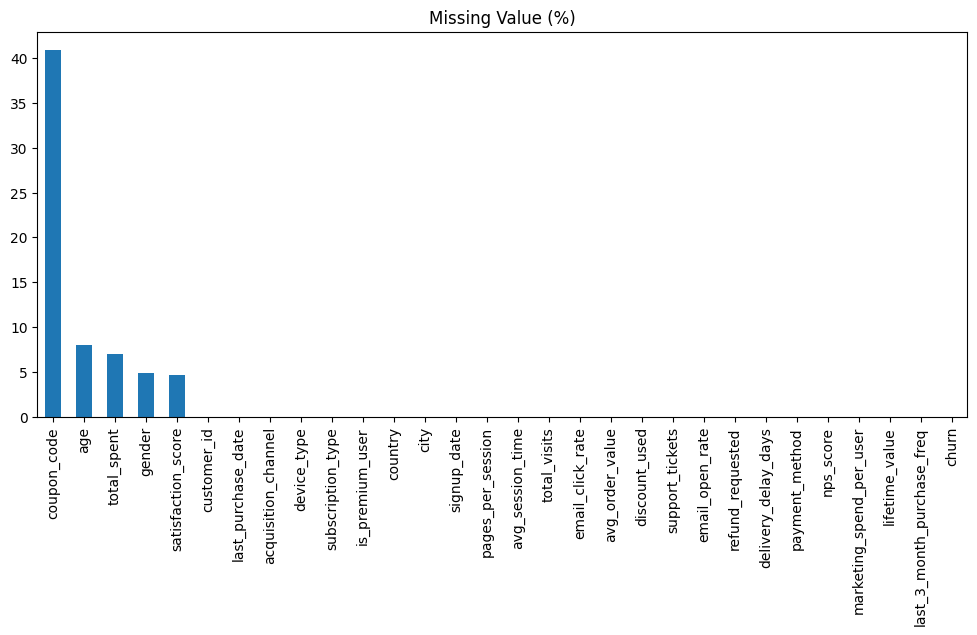

In [7]:
#visualisasi missing value
plt.figure(figsize=(12,5))

missing.sort_values(
    ascending=False
).plot(kind='bar')

plt.title("Missing Value (%)")

plt.show()

In [8]:
#cek duplicate
print(
    "Jumlah Duplicate :",
    df.duplicated().sum()
)

Jumlah Duplicate : 0


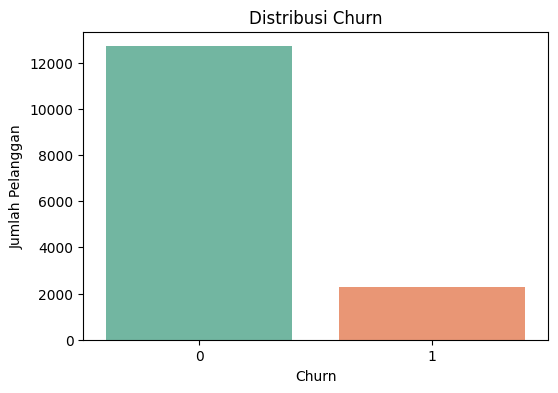

In [9]:
# distribusi churn

plt.figure(figsize=(6,4))

sns.countplot(
    x='churn',
    data=df,
    palette='Set2'
)

plt.title("Distribusi Churn")
plt.xlabel("Churn")
plt.ylabel("Jumlah Pelanggan")

plt.show()

In [10]:
# presentase churn

df['churn'].value_counts(normalize=True) * 100

,proportion
churn,
0,84.68
1,15.32


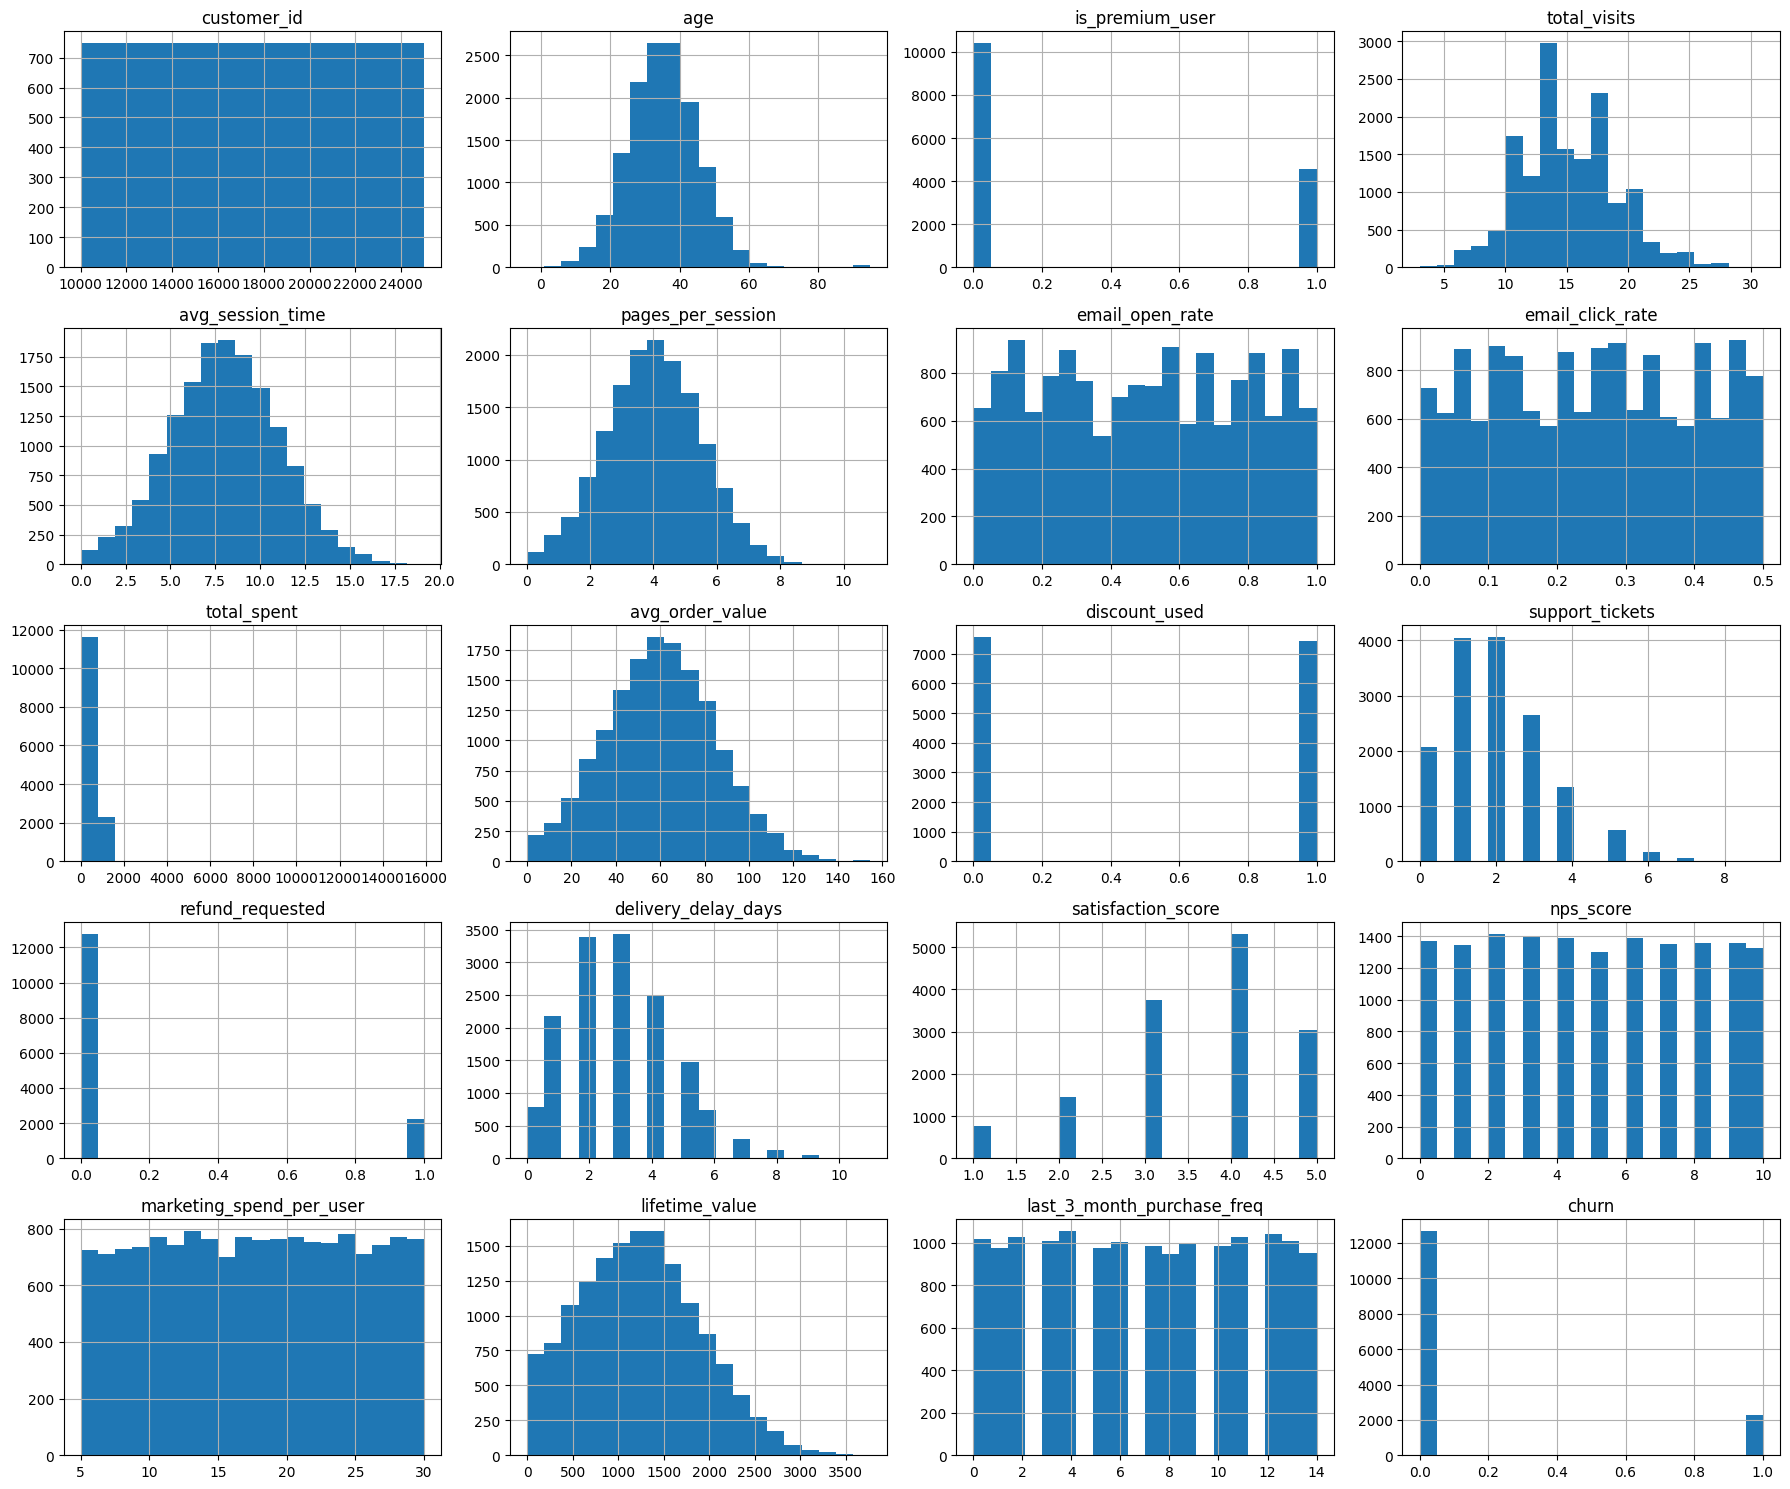

In [11]:
#distribusi fitur numerik
numeric_cols = df.select_dtypes(
    include=np.number
).columns

df[numeric_cols].hist(
    figsize=(18,15),
    bins=20
)

plt.tight_layout()

plt.show()

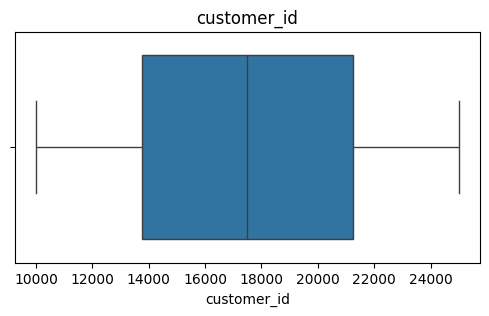

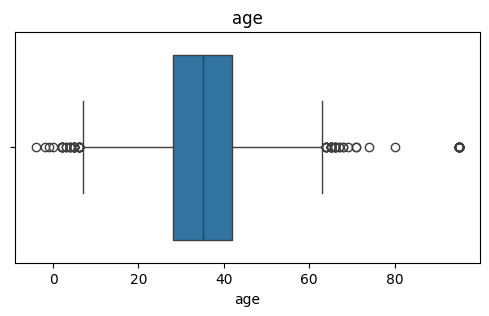

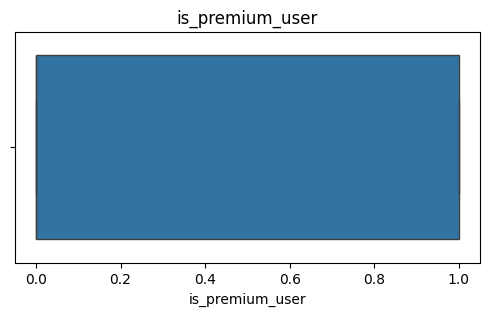

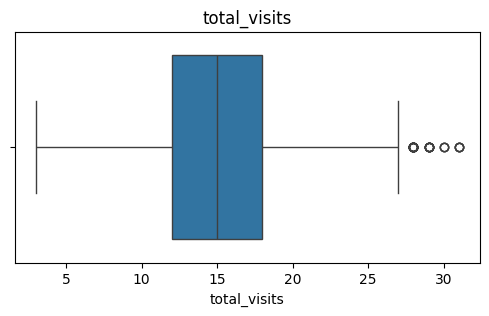

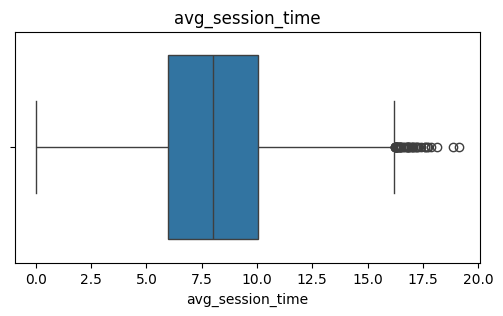

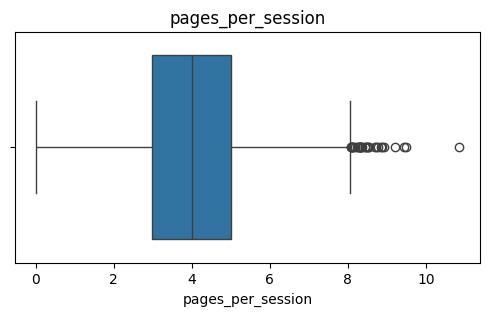

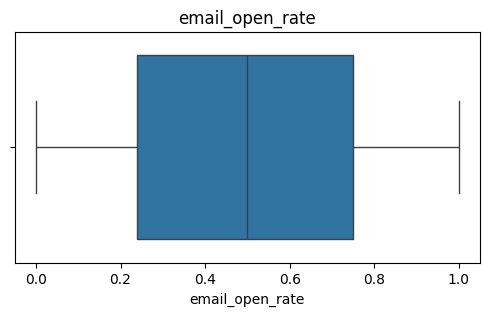

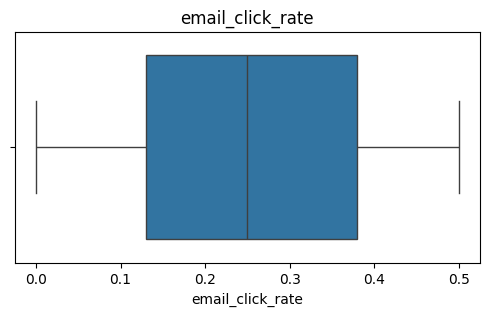

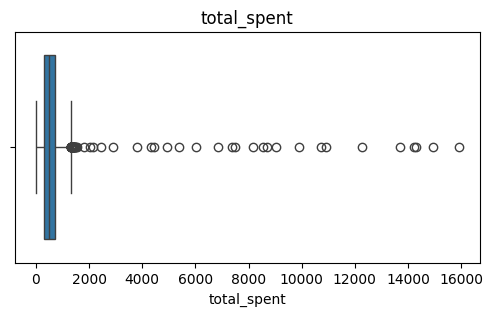

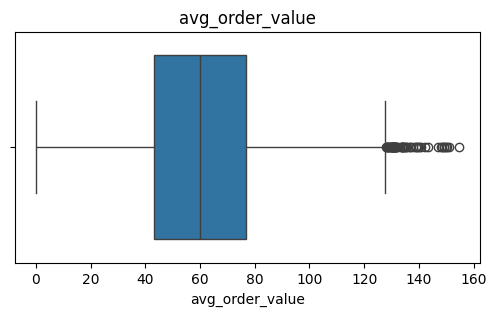

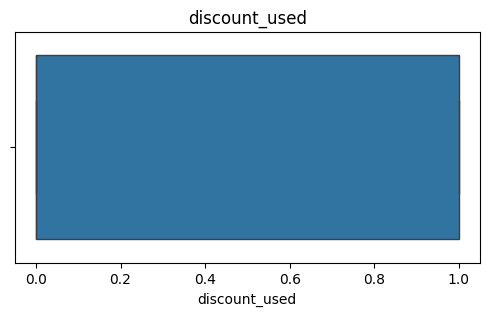

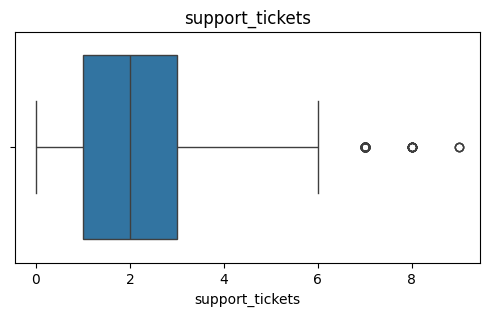

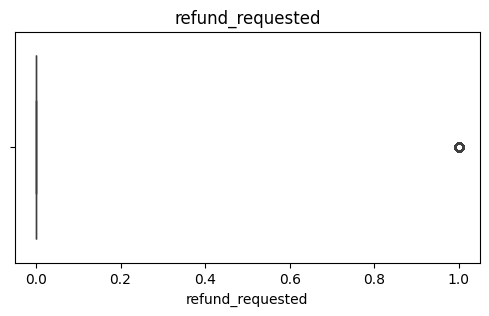

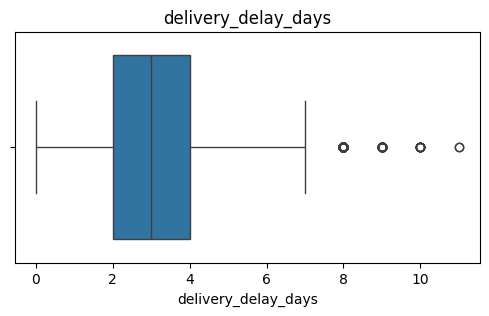

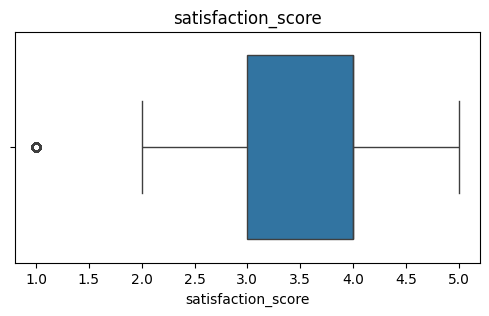

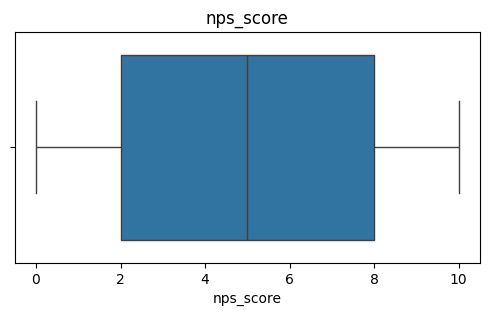

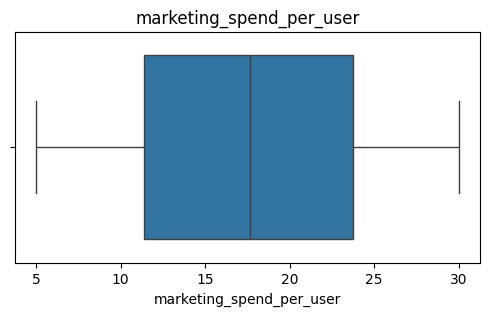

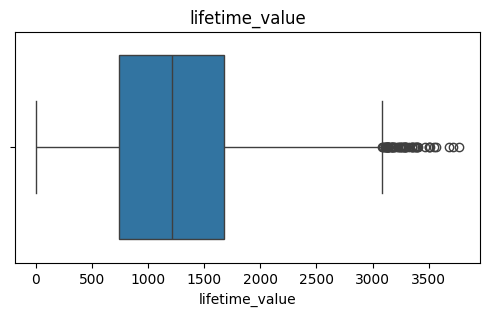

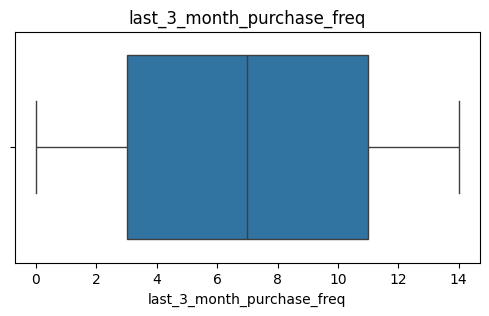

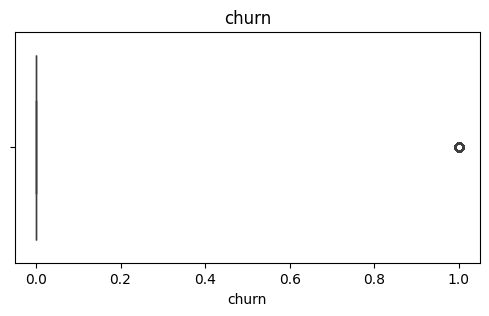

In [12]:
#Boxplot Semua Fitur Numerik
for col in numeric_cols:

    plt.figure(figsize=(6,3))

    sns.boxplot(
        x=df[col]
    )

    plt.title(col)

    plt.show()

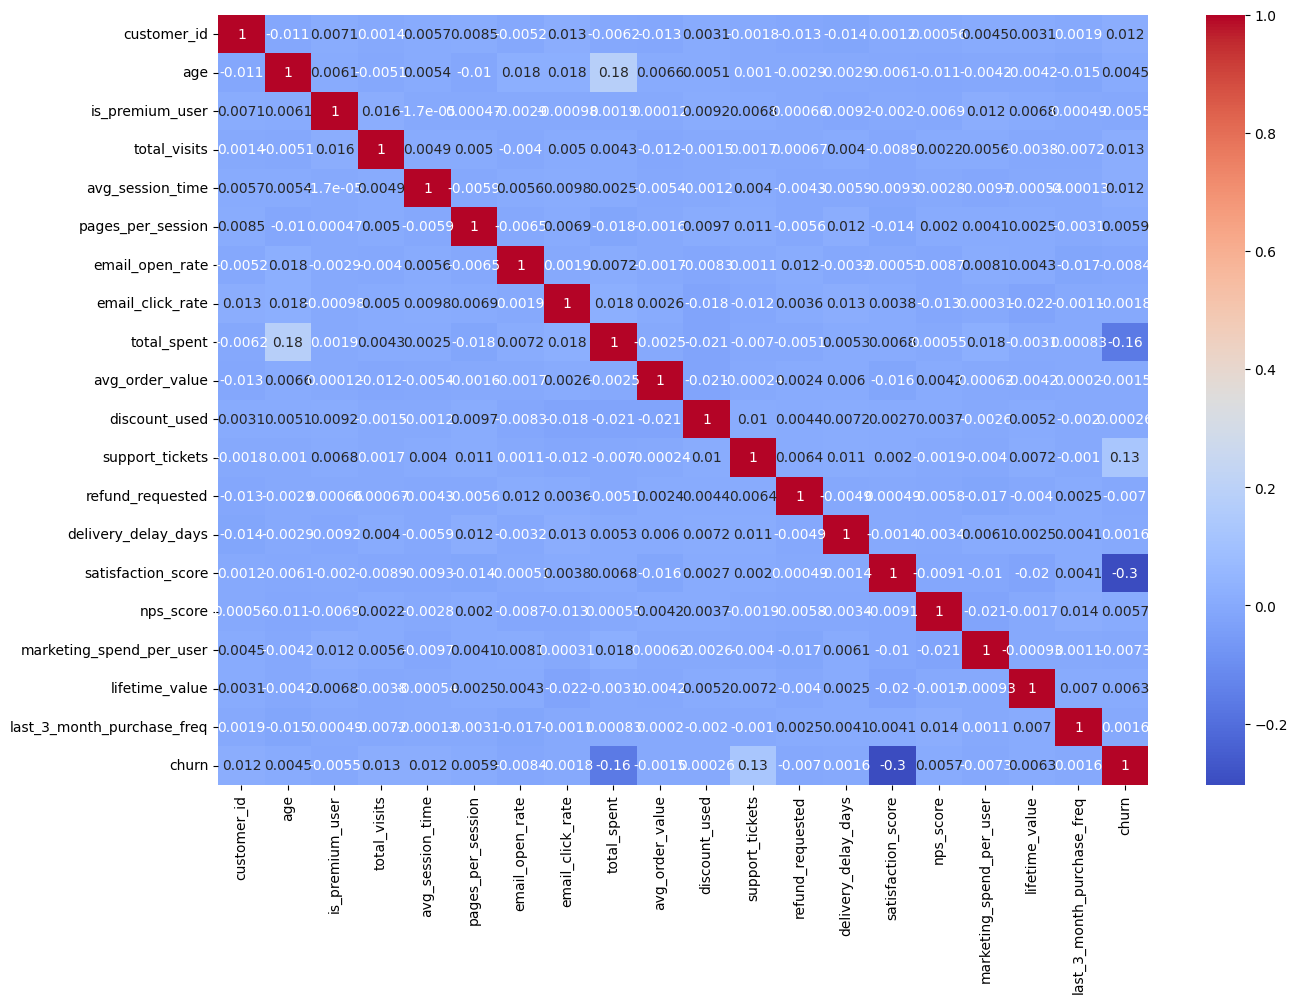

In [13]:
# heatmap korelasi

plt.figure(figsize=(15,10))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [14]:
# Korelasi terhadap churn

corr_churn = (
    df[numeric_cols]
    .corr()['churn']
    .sort_values(
        ascending=False
    )
)

corr_churn

,churn
churn,1.000000
support_tickets,0.127910
total_visits,0.013212
customer_id,0.012208
avg_session_time,0.012198
lifetime_value,0.006250
pages_per_session,0.005871
nps_score,0.005749
age,0.004506
delivery_delay_days,0.001603


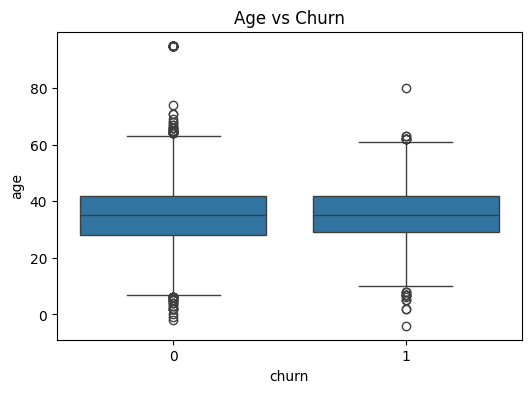

In [15]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x='churn',
    y='age',
    data=df
)

plt.title("Age vs Churn")
plt.show()

Digunakan untuk melihat apakah terdapat perbedaan usia antara pelanggan churn dan tidak churn.

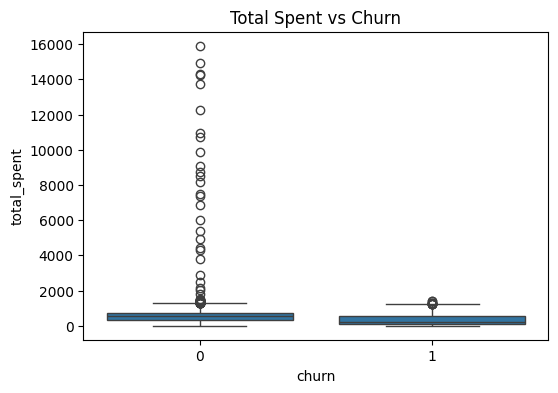

In [16]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x='churn',
    y='total_spent',
    data=df
)

plt.title("Total Spent vs Churn")
plt.show()

Digunakan untuk mengetahui hubungan total pengeluaran pelanggan terhadap kemungkinan churn.

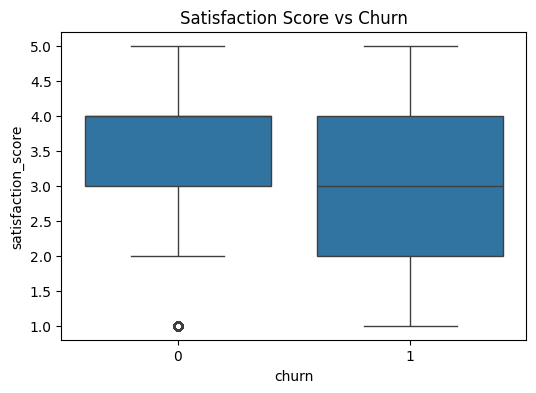

In [17]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x='churn',
    y='satisfaction_score',
    data=df
)

plt.title("Satisfaction Score vs Churn")
plt.show()

Digunakan untuk menganalisis pengaruh tingkat kepuasan pelanggan terhadap churn.

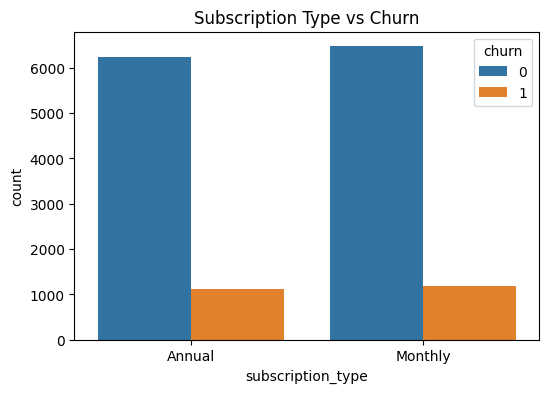

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='subscription_type',
    hue='churn',
    data=df
)

plt.title("Subscription Type vs Churn")
plt.show()

Digunakan untuk melihat perbedaan tingkat churn antara pelanggan berlangganan bulanan dan tahunan.

# soal nomer 2 Direct Modeling

(Technical Adjustment Only)

In [27]:
for col in df.select_dtypes(include='object').columns:

    df[col] = df[col].fillna(
        df[col].mode()[0]
    )

for col in df.select_dtypes(include=np.number).columns:

    df[col] = df[col].fillna(
        df[col].median()
    )

In [28]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:

    df[col] = le.fit_transform(
        df[col].astype(str)
    )

In [31]:
#menentukan x dan y
X_direct = df.drop(
    'churn',
    axis=1
)

y_direct = df['churn']

In [33]:
#train test split
X_train_direct, X_test_direct, y_train_direct, y_test_direct = train_test_split(
    X_direct,
    y_direct,
    test_size=0.2,
    random_state=42
)

In [34]:
# LOGISTIC REGRESSION

lr_direct = LogisticRegression(
    max_iter=1000
)

lr_direct.fit(
    X_train_direct,
    y_train_direct
)

y_pred_lr_direct = lr_direct.predict(
    X_test_direct
)

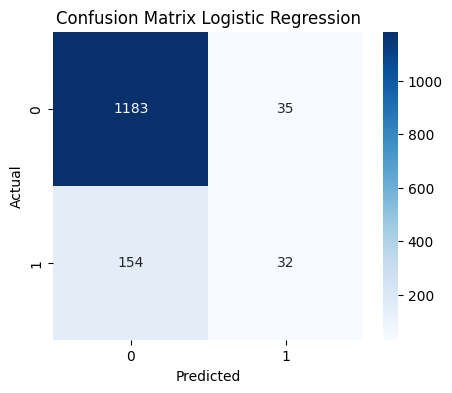

In [60]:
cm_lr = confusion_matrix(
    y_test_pre,
    y_pred_lr_pre
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [62]:
# RANDOM FOREST

rf_direct = RandomForestClassifier(
    random_state=42
)

rf_direct.fit(
    X_train_direct,
    y_train_direct
)

y_pred_rf_direct = rf_direct.predict(
    X_test_direct
)

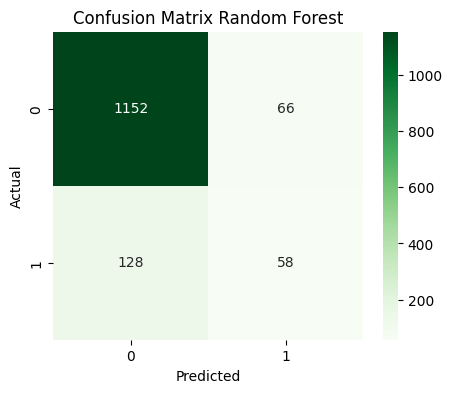

In [63]:
cm_rf = confusion_matrix(
    y_test_pre,
    y_pred_rf_pre
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title('Confusion Matrix Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [64]:
# VOTING CLASSIFIER

voting_direct = VotingClassifier(

    estimators=[

        ('lr', LogisticRegression(max_iter=1000)),

        ('knn', KNeighborsClassifier()),

        ('svc', SVC())

    ],

    voting='hard'
)

voting_direct.fit(
    X_train_direct,
    y_train_direct
)

y_pred_voting_direct = voting_direct.predict(
    X_test_direct
)

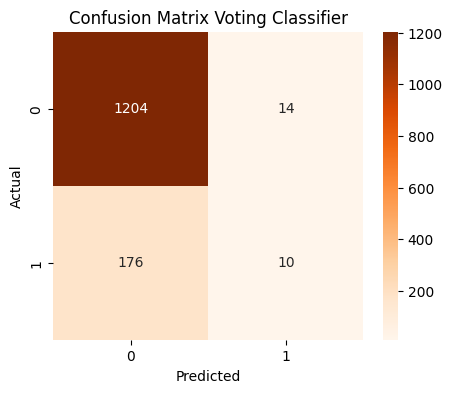

In [65]:
cm_voting = confusion_matrix(
    y_test_pre,
    y_pred_voting_pre
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_voting,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title('Confusion Matrix Voting Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [66]:
#Evaluasi
print("Accuracy :",
      accuracy_score(y_test_direct, y_pred_lr_direct))

print("Precision :",
      precision_score(y_test_direct, y_pred_lr_direct))

print("Recall :",
      recall_score(y_test_direct, y_pred_lr_direct))

print("F1 Score :",
      f1_score(y_test_direct, y_pred_lr_direct))

Accuracy : 0.8513333333333334
Precision : 0.4934210526315789
Recall : 0.16891891891891891
F1 Score : 0.2516778523489933


In [68]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Voting Classifier'
    ],
    'Accuracy': [
        accuracy_score(y_test_direct, y_pred_lr_direct),
        accuracy_score(y_test_direct, y_pred_rf_direct),
        accuracy_score(y_test_direct, y_pred_voting_direct)
    ],
    'Precision': [
        precision_score(y_test_direct, y_pred_lr_direct),
        precision_score(y_test_direct, y_pred_rf_direct),
        precision_score(y_test_direct, y_pred_voting_direct)
    ],
    'Recall': [
        recall_score(y_test_direct, y_pred_lr_direct),
        recall_score(y_test_direct, y_pred_rf_direct),
        recall_score(y_test_direct, y_pred_voting_direct)
    ],
    'F1 Score': [
        f1_score(y_test_direct, y_pred_lr_direct),
        f1_score(y_test_direct, y_pred_rf_direct),
        f1_score(y_test_direct, y_pred_voting_direct)
    ]
})

results.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
2,Voting Classifier,0.854667,0.666667,0.036036,0.068376
1,Random Forest,0.854000,0.510417,0.331081,0.401639
0,Logistic Regression,0.851333,0.493421,0.168919,0.251678


# soal ke 2 Modeling Dengan Preprocessing

In [200]:
#copy data
df_pre = df.copy()

In [201]:
# missing value handling

for col in df_pre.select_dtypes(include='object').columns:

    df_pre[col] = df_pre[col].fillna(
        df_pre[col].mode()[0]
    )

for col in df_pre.select_dtypes(include=np.number).columns:

    df_pre[col] = df_pre[col].fillna(
        df_pre[col].median()
    )

In [202]:
#cek missing value
print(df_pre.isnull().sum().sum())

0


In [203]:
# duplicate handling

print("Duplicate Sebelum :",
      df_pre.duplicated().sum())

df_pre.drop_duplicates(
    inplace=True
)

print("Duplicate Sesudah :",
      df_pre.duplicated().sum())

Duplicate Sebelum : 0
Duplicate Sesudah : 0


In [204]:
# outlier handling

numeric_cols = df_pre.select_dtypes(
    include=np.number
).columns

for col in numeric_cols:

    if col != 'churn':

        Q1 = df_pre[col].quantile(0.25)
        Q3 = df_pre[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - (1.5 * IQR)
        upper = Q3 + (1.5 * IQR)

        df_pre = df_pre[
            (df_pre[col] >= lower) &
            (df_pre[col] <= upper)
        ]

In [205]:
#drop fitur tidak relevan
if 'customer_id' in df_pre.columns:

    df_pre.drop(
        'customer_id',
        axis=1,
        inplace=True
    )

In [206]:
# encoding

le = LabelEncoder()

for col in df_pre.select_dtypes(include='object').columns:

    df_pre[col] = le.fit_transform(
        df_pre[col].astype(str)
    )

In [207]:
#menentukan x dan y
X_pre = df_pre.drop(
    'churn',
    axis=1
)

y_pre = df_pre['churn']

In [208]:
#train test split
X_train_pre, X_test_pre, y_train_pre, y_test_pre = train_test_split(
    X_pre,
    y_pre,
    test_size=0.2,
    random_state=42
)

In [209]:
#scaling
scaler = StandardScaler()

X_train_pre = scaler.fit_transform(
    X_train_pre
)

X_test_pre = scaler.transform(
    X_test_pre
)

In [210]:
#smote
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

X_train_pre, y_train_pre = smote.fit_resample(
    X_train_pre,
    y_train_pre
)

print("Distribusi Setelah SMOTE")
print(y_train_pre.value_counts())

Distribusi Setelah SMOTE
churn
0    4877
1    4877
Name: count, dtype: int64


In [211]:
#model Logistic Regression
lr_pre = LogisticRegression(
    max_iter=1000
)

lr_pre.fit(
    X_train_pre,
    y_train_pre
)

y_pred_lr_pre = lr_pre.predict(
    X_test_pre
)

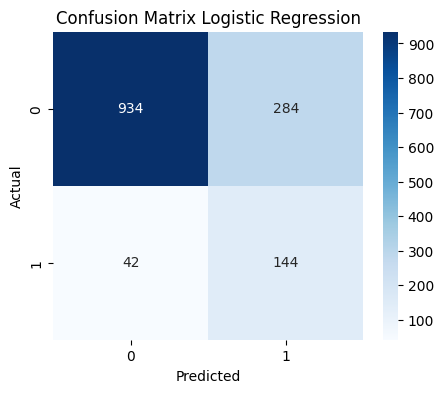

In [212]:
cm_lr = confusion_matrix(
    y_test_pre,
    y_pred_lr_pre
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    'Confusion Matrix Logistic Regression'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [213]:
#model Random Forest
rf_pre = RandomForestClassifier(
    random_state=42
)

rf_pre.fit(
    X_train_pre,
    y_train_pre
)

y_pred_rf_pre = rf_pre.predict(
    X_test_pre
)

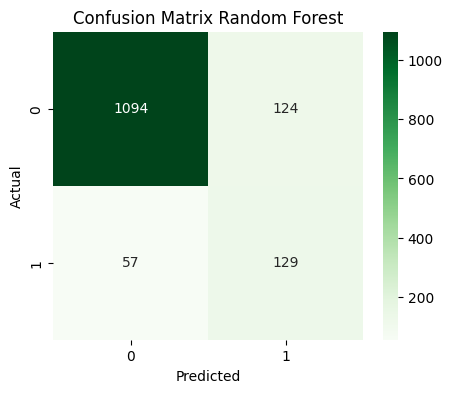

In [214]:
cm_rf = confusion_matrix(
    y_test_pre,
    y_pred_rf_pre
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title(
    'Confusion Matrix Random Forest'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [215]:
#model Voting Classifier
voting_pre = VotingClassifier(

    estimators=[

        ('lr',
         LogisticRegression(max_iter=1000)),

        ('knn',
         KNeighborsClassifier()),

        ('svc',
         SVC())

    ],

    voting='hard'
)

voting_pre.fit(
    X_train_pre,
    y_train_pre
)

y_pred_voting_pre = voting_pre.predict(
    X_test_pre
)

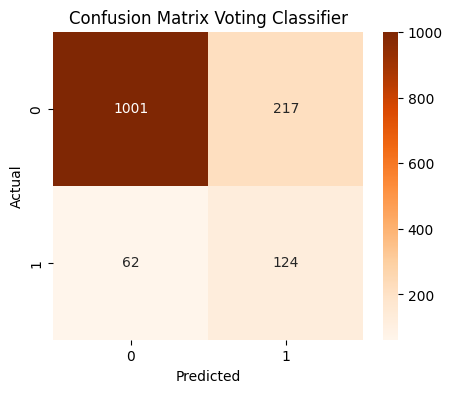

In [216]:
cm_voting = confusion_matrix(
    y_test_pre,
    y_pred_voting_pre
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_voting,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title(
    'Confusion Matrix Voting Classifier'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [217]:
#Evaluasi Semua Model
results_pre = pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'Random Forest',
        'Voting Classifier'
    ],
    'Accuracy':[
        accuracy_score(y_test_pre,y_pred_lr_pre),
        accuracy_score(y_test_pre,y_pred_rf_pre),
        accuracy_score(y_test_pre,y_pred_voting_pre)
    ],
    'Precision':[
        precision_score(y_test_pre,y_pred_lr_pre),
        precision_score(y_test_pre,y_pred_rf_pre),
        precision_score(y_test_pre,y_pred_voting_pre)
    ],
    'Recall':[
        recall_score(y_test_pre,y_pred_lr_pre),
        recall_score(y_test_pre,y_pred_rf_pre),
        recall_score(y_test_pre,y_pred_voting_pre)
    ],
    'F1 Score':[
        f1_score(y_test_pre,y_pred_lr_pre),
        f1_score(y_test_pre,y_pred_rf_pre),
        f1_score(y_test_pre,y_pred_voting_pre)
    ]
})

results_pre

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.767806,0.336449,0.774194,0.469055
1,Random Forest,0.871083,0.509881,0.693548,0.587699
2,Voting Classifier,0.801282,0.363636,0.666667,0.470588


# soal 3

FEATURE IMPORTANCE
                       Feature  Importance
15                 total_spent    0.264375
23          satisfaction_score    0.254853
19             support_tickets    0.094034
0                       gender    0.024680
6          acquisition_channel    0.024532
2                      country    0.023989
3                         city    0.023923
7                  device_type    0.023137
24                   nps_score    0.019864
22              payment_method    0.019785
5           last_purchase_date    0.018303
25    marketing_spend_per_user    0.018223
26              lifetime_value    0.016571
14            email_click_rate    0.016444
21         delivery_delay_days    0.016310
4                  signup_date    0.015806
11            avg_session_time    0.015459
10                total_visits    0.015235
27  last_3_month_purchase_freq    0.015234
1                          age    0.015182
13             email_open_rate    0.014903
16             avg_order_value    0

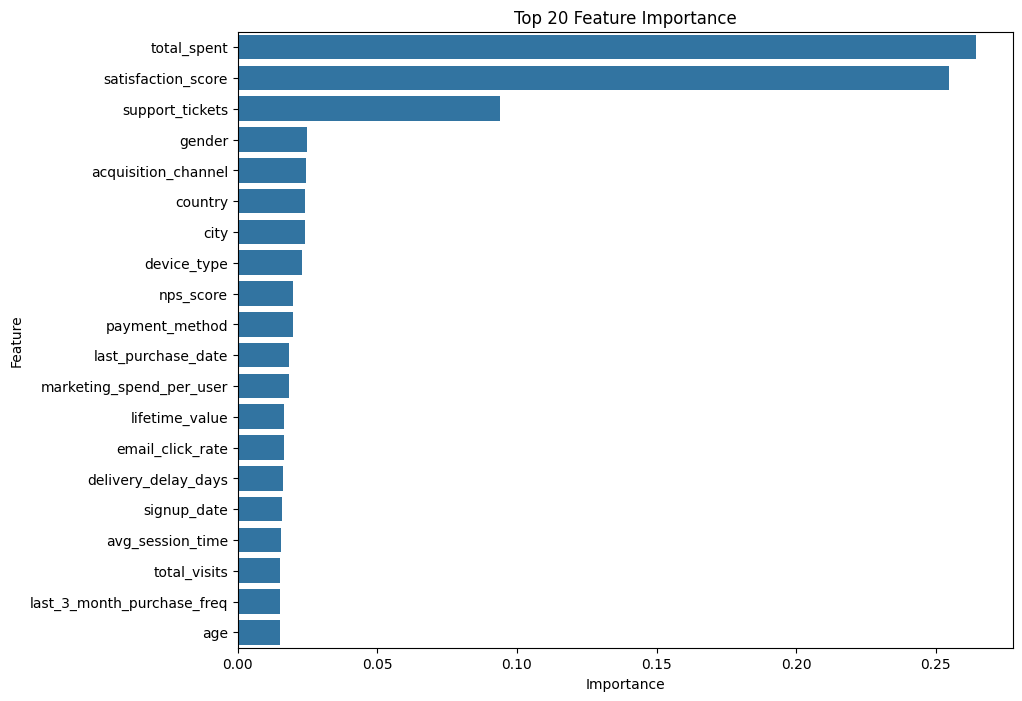

In [219]:
# FEATURE IMPORTANCE

print("="*60)
print("FEATURE IMPORTANCE")
print("="*60)

rf_feature = RandomForestClassifier(
    random_state=42
)

rf_feature.fit(
    X_train_pre,
    y_train_pre
)

feature_importance = pd.DataFrame({
    'Feature': X_pre.columns,
    'Importance': rf_feature.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

plt.figure(figsize=(10,8))

sns.barplot(
    data=feature_importance.head(20),
    x='Importance',
    y='Feature'
)

plt.title('Top 20 Feature Importance')
plt.show()

Hyperparameter Tuning Logistic Regression

In [220]:
print("="*60)
print("TUNING LOGISTIC REGRESSION")
print("="*60)

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear'],
    'class_weight': ['balanced']
}

grid_lr = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=5000,
        random_state=42
    ),
    param_grid=param_grid_lr,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_lr.fit(
    X_train_pre,
    y_train_pre
)

best_lr = grid_lr.best_estimator_

print("Best Parameter LR:")
print(grid_lr.best_params_)

TUNING LOGISTIC REGRESSION
Best Parameter LR:
{'C': 0.01, 'class_weight': 'balanced', 'solver': 'liblinear'}


LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.96      0.75      0.84      1218
           1       0.33      0.78      0.46       186

    accuracy                           0.76      1404
   macro avg       0.64      0.77      0.65      1404
weighted avg       0.87      0.76      0.79      1404



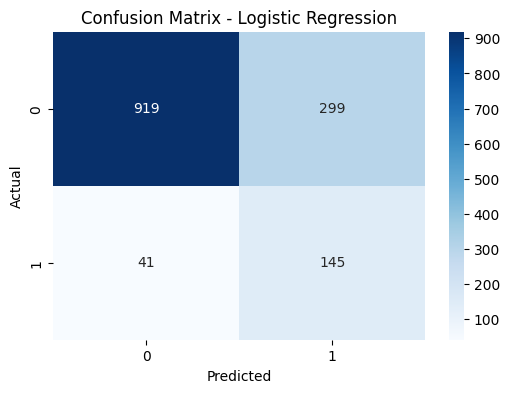

In [221]:
print("="*60)
print("LOGISTIC REGRESSION")
print("="*60)

y_pred_lr = best_lr.predict(X_test_pre)

print(
    classification_report(
        y_test_pre,
        y_pred_lr
    )
)

cm_lr = confusion_matrix(
    y_test_pre,
    y_pred_lr
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

Hyperparameter Tuning Random Forest

In [222]:
print("="*60)
print("TUNING LOGISTIC REGRESSION")
print("="*60)

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear'],
    'class_weight': ['balanced']
}

grid_lr = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=5000,
        random_state=42
    ),
    param_grid=param_grid_lr,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_lr.fit(
    X_train_pre,
    y_train_pre
)

best_lr = grid_lr.best_estimator_

print("Best Parameter LR:")
print(grid_lr.best_params_)


TUNING LOGISTIC REGRESSION
Best Parameter LR:
{'C': 0.01, 'class_weight': 'balanced', 'solver': 'liblinear'}


RANDOM FOREST
              precision    recall  f1-score   support

           0       0.90      0.95      0.92      1218
           1       0.49      0.32      0.39       186

    accuracy                           0.87      1404
   macro avg       0.70      0.64      0.66      1404
weighted avg       0.85      0.87      0.85      1404



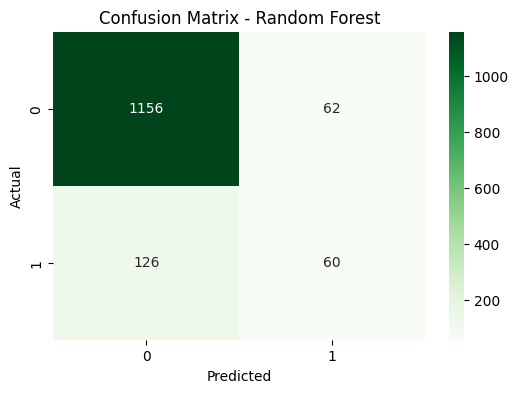

In [224]:
print("="*60)
print("RANDOM FOREST")
print("="*60)

y_pred_rf = best_rf.predict(X_test_fs)

print(
    classification_report(
        y_test_fs,
        y_pred_rf
    )
)

cm_rf = confusion_matrix(
    y_test_fs,
    y_pred_rf
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

Hyperparameter Tuning Voting Classifier

In [225]:
print("="*60)
print("TRAINING VOTING CLASSIFIER")
print("="*60)

best_voting = VotingClassifier(
    estimators=[
        ('lr', best_lr),
        ('rf', best_rf),
        ('knn', KNeighborsClassifier())
    ],
    voting='soft'
)

best_voting.fit(
    X_train_pre,
    y_train_pre
)


TRAINING VOTING CLASSIFIER


VotingClassifier(estimators=[('lr',
                              LogisticRegression(C=0.01,
                                                 class_weight='balanced',
                                                 max_iter=5000, random_state=42,
                                                 solver='liblinear')),
                             ('rf',
                              RandomForestClassifier(max_depth=15,
                                                     n_estimators=200,
                                                     random_state=42)),
                             ('knn', KNeighborsClassifier())],
                 voting='soft')

VOTING CLASSIFIER
              precision    recall  f1-score   support

           0       0.96      0.85      0.90      1218
           1       0.44      0.75      0.55       186

    accuracy                           0.84      1404
   macro avg       0.70      0.80      0.73      1404
weighted avg       0.89      0.84      0.85      1404



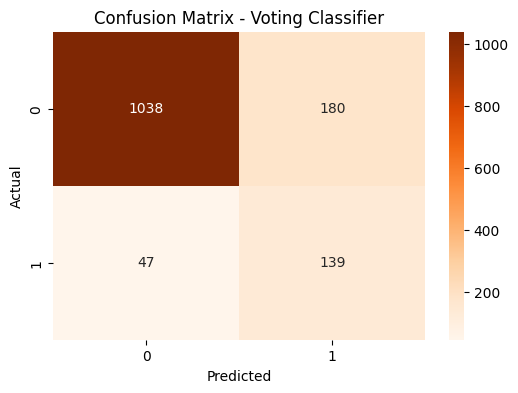

In [226]:
print("="*60)
print("VOTING CLASSIFIER")
print("="*60)

y_pred_voting = best_voting.predict(X_test_pre)

print(
    classification_report(
        y_test_pre,
        y_pred_voting
    )
)

cm_voting = confusion_matrix(
    y_test_pre,
    y_pred_voting
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_voting,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title('Confusion Matrix - Voting Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()


Tabel Perbandingan Akhir

In [227]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Voting Classifier'
    ],
    'Accuracy': [
        accuracy_score(y_test_pre, y_pred_lr),
        accuracy_score(y_test_pre, y_pred_rf),
        accuracy_score(y_test_pre, y_pred_voting)
    ],
    'Precision': [
        precision_score(y_test_pre, y_pred_lr),
        precision_score(y_test_pre, y_pred_rf),
        precision_score(y_test_pre, y_pred_voting)
    ],
    'Recall': [
        recall_score(y_test_pre, y_pred_lr),
        recall_score(y_test_pre, y_pred_rf),
        recall_score(y_test_pre, y_pred_voting)
    ],
    'F1 Score': [
        f1_score(y_test_pre, y_pred_lr),
        f1_score(y_test_pre, y_pred_rf),
        f1_score(y_test_pre, y_pred_voting)
    ]
})

results = results.sort_values(
    by='F1 Score',
    ascending=False
)

print("="*60)
print("HASIL EVALUASI SELURUH MODEL")
print("="*60)

print(results)


HASIL EVALUASI SELURUH MODEL
                 Model  Accuracy  Precision    Recall  F1 Score
2    Voting Classifier  0.838319   0.435737  0.747312  0.550495
0  Logistic Regression  0.757835   0.326577  0.779570  0.460317
1        Random Forest  0.866097   0.491803  0.322581  0.389610


In [228]:
# SIMPAN MODEL TERBAIK

best_model_name = results.iloc[0]['Model']

print("\nMODEL TERBAIK:")
print(best_model_name)



MODEL TERBAIK:
Voting Classifier


In [230]:
import joblib

joblib.dump(
    best_voting,
    "best_model.pkl"
)

print("Voting Classifier berhasil disimpan")

Voting Classifier berhasil disimpan


In [232]:
joblib.dump(
    scaler,
    "scaler.pkl"
)

['scaler.pkl']